<a href="https://colab.research.google.com/github/Ebrardemir/amazon-sentiment-analysis/blob/main/notebooks/03_Veri_onisleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

# Drive'ı bağlayalım
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Görselleştirme ayarları
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

In [ ]:
input_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/main_kategori_orneklem.csv'

In [ ]:
import pandas as pd

def veriyi_oku_ve_goster(input_path):

    df = pd.read_csv(input_path)
    print("Veri seti başarıyla okundu. İşte ilk 5 satır:\n")
    display(df.head())
    return df
df = veriyi_oku_ve_goster(input_path)

Veri seti başarıyla okundu. İşte ilk 5 satır:



,main_category,parent_asin,user_id,rating,title,text,timestamp,helpful_vote,verified_purchase
0,AMAZON FASHION,B07C1JV4D6,AHFNZX5F56JGJB3YNWA57ZN4APXA,1,Decrease in quality,I previously purchased this band and wire it f...,1580012908597,0,True
1,AMAZON FASHION,B07Y1WXKK7,AGKJS7CWFAIMUF3XSZBD2PLYWPJA,1,Sizing is poor,For slim nine year old the small was way too s...,1628407422155,0,True
2,AMAZON FASHION,B0B5LM3BM4,AHPWHEPY6LTUH3GAB6B2CXAEJ5GQ,1,Band not as pictured,The band I recieved is NOT what was pictured. ...,1607109744225,0,True
3,AMAZON FASHION,B07RM3SH7T,AGCXKLCXMUBUGFDY4EIE6FISFLWQ,1,Didn't come in color that was shown,Didn't come in color that was shown,1646075961857,0,True
4,AMAZON FASHION,B093RXLDX3,AEMPA7MRAT4S6MZHV4W3GTBZVKRQ,1,Don’t buy,They do not work! You can not get the one side...,1675717611577,0,True


In [ ]:
def eksik_verileri_temizle_v2(df):
    """
    Model eğitiminde kullanılacak olan 'text' ve 'title' sütunlarının
    her ikisinin de dolu olduğundan emin olur. Eksik olan satırları siler.
    """
    # Başlangıçtaki satır sayısını kaydedelim
    ilk_boyut = len(df)

    # 1. Hem 'text' hem de 'title' sütunlarına bakıyoruz.
    # Bu sütunlardan herhangi biri (how='any') NaN ise o satırı siliyoruz.
    df.dropna(subset=['text', 'title'], how='any', inplace=True)

    # Son durumu hesaplayalım
    son_boyut = len(df)
    silinen_sayisi = ilk_boyut - son_boyut

    print("*** EKSİK VERİ TEMİZLİĞİ (TEXT & TITLE) TAMAMLANDI ***")
    print(f"Başlangıç Satır Sayısı: {ilk_boyut}")
    print(f"Silinen Satır Sayısı  : {silinen_sayisi}")
    print(f"Kalan Satır Sayısı     : {son_boyut}")
    print(f"Veri Setinin Yeni Boyutu: {df.shape}")

    return df

# --- KULLANIM ---
df = eksik_verileri_temizle_v2(df)

*** EKSİK VERİ TEMİZLİĞİ (TEXT & TITLE) TAMAMLANDI ***
Başlangıç Satır Sayısı: 573500
Silinen Satır Sayısı  : 166
Kalan Satır Sayısı     : 573334
Veri Setinin Yeni Boyutu: (573334, 9)


In [ ]:
def yorum_istatistiklerini_uret(df):

    print("*** YORUM İSTATİSTİKLERİ TÜRETİLİYOR ***")

    # 1. Karakter Sayısı (Boşluklar dahil toplam uzunluk)
    df['char_count'] = df['text'].astype(str).apply(len)

    # 2. Kelime Sayısı (Metni boşluklardan bölüp sayar)
    df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

    # 3. Ünlem (!) Sayısı
    df['exclamation_count'] = df['text'].astype(str).apply(lambda x: x.count('!'))

    # 4. Soru İşareti (?) Sayısı
    df['question_count'] = df['text'].astype(str).apply(lambda x: x.count('?'))

    # 5. Büyük Harf Sayısı (Bağırma tespiti için)
    # sum(1 for c in x if c.isupper()) metindeki her karakteri gezer ve büyükse 1 sayar
    df['uppercase_count'] = df['text'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()))

    print(" Özellikler başarıyla eklendi.")

    # Sonuçları kontrol etmek için örnek sütunları gösterelim
    istatistik_sutunlari = ['text', 'char_count', 'word_count', 'exclamation_count', 'question_count', 'uppercase_count']
    display(df[istatistik_sutunlari].head(10))

    return df

df = yorum_istatistiklerini_uret(df)

*** YORUM İSTATİSTİKLERİ TÜRETİLİYOR ***
 Özellikler başarıyla eklendi.


,text,char_count,word_count,exclamation_count,question_count,uppercase_count
0,I previously purchased this band and wire it f...,241,43,0,0,5
1,For slim nine year old the small was way too s...,113,23,0,0,3
2,The band I recieved is NOT what was pictured. ...,112,24,0,0,6
3,Didn't come in color that was shown,35,7,0,0,1
4,They do not work! You can not get the one side...,185,40,3,0,5
5,Does not fit my fenix 5s plus. Way too big.ughh,47,10,0,0,2
6,This package included two wristbands: the firs...,202,33,0,0,2
7,Not what I thought it would be. The quality se...,1475,292,5,1,44
8,I didn’t like the look..,24,5,0,0,1
9,"beautiful band, but is NOT compatible with my ...",69,10,0,0,5


In [ ]:
# Sadece bu 3 satırı yeni bir hücreye yazman yeterli
import pandas as pd
pd.set_option('display.max_columns', None) # Tüm sütunları görmek için
display(df.head(10)) # Orijinal + Yeni 5 sütun dahil tüm tabloyu gösterir

,main_category,parent_asin,user_id,rating,title,text,timestamp,helpful_vote,verified_purchase,char_count,word_count,exclamation_count,question_count,uppercase_count
0,AMAZON FASHION,B07C1JV4D6,AHFNZX5F56JGJB3YNWA57ZN4APXA,1,Decrease in quality,I previously purchased this band and wire it f...,1580012908597,0,True,241,43,0,0,5
1,AMAZON FASHION,B07Y1WXKK7,AGKJS7CWFAIMUF3XSZBD2PLYWPJA,1,Sizing is poor,For slim nine year old the small was way too s...,1628407422155,0,True,113,23,0,0,3
2,AMAZON FASHION,B0B5LM3BM4,AHPWHEPY6LTUH3GAB6B2CXAEJ5GQ,1,Band not as pictured,The band I recieved is NOT what was pictured. ...,1607109744225,0,True,112,24,0,0,6
3,AMAZON FASHION,B07RM3SH7T,AGCXKLCXMUBUGFDY4EIE6FISFLWQ,1,Didn't come in color that was shown,Didn't come in color that was shown,1646075961857,0,True,35,7,0,0,1
4,AMAZON FASHION,B093RXLDX3,AEMPA7MRAT4S6MZHV4W3GTBZVKRQ,1,Don’t buy,They do not work! You can not get the one side...,1675717611577,0,True,185,40,3,0,5
5,AMAZON FASHION,B077SFTGYW,AG6INTYDWNARVXOWVOOXNSPLZODA,1,Does not fit 5x plus,Does not fit my fenix 5s plus. Way too big.ughh,1567265437717,0,True,47,10,0,0,2
6,AMAZON FASHION,B0B52Y3P49,AHT52WEYXRYJ5X3OLZQ422OOLHKQ,1,Does not connect to the Sense Face,This package included two wristbands: the firs...,1659982703310,0,True,202,33,0,0,2
7,AMAZON FASHION,B07PSK9PX5,AHIOGRM7NGJZCTJHKV4S2Y2EX2KQ,1,Buyer beware! So disappointed...,Not what I thought it would be. The quality se...,1543449486492,12,True,1475,292,5,1,44
8,AMAZON FASHION,B07HD1RMZ4,AGEV5KB3CP5XJMRR6E4MKYIIPZZQ,1,Doesn’t look cute,I didn’t like the look..,1553648665254,0,True,24,5,0,0,1
9,AMAZON FASHION,B09F5TVT11,AFDUYY7CEFUHGOQTWBVAX2QJA7JQ,1,This product is NOT compatible with Fitbit HR,"beautiful band, but is NOT compatible with my ...",1646695798094,0,False,69,10,0,0,5


In [ ]:
import os

# Senin belirttiğin yol üzerinden devam ediyoruz
kayit_yolu = '/content/drive/MyDrive/Veri_madenciliği/Dataset/'
dosya_adi = "amazon_reviews_statistics.csv"
tam_yol = os.path.join(kayit_yolu, dosya_adi)

print(f" Zenginleştirilmiş veri seti kaydediliyor: {dosya_adi}")

# index=False: Satır numaralarını sütun olarak eklemez
# encoding='utf-8-sig': Excel'de açtığında karakter sorunu yaşamanı engeller
df.to_csv(tam_yol, index=False, encoding='utf-8-sig')

print(f" Başarıyla kaydedildi! Dosyanı Drive'daki şu konumda bulabilirsin:\n{tam_yol}")

 Zenginleştirilmiş veri seti kaydediliyor: amazon_reviews_statistics.csv
 Başarıyla kaydedildi! Dosyanı Drive'daki şu konumda bulabilirsin:
/content/drive/MyDrive/Veri_madenciliği/Dataset/amazon_reviews_statistics.csv


In [ ]:

import pandas as pd
import re
import os

# 1. Dosya Yolunu Tanımlayalım (İstatistikli olan en güncel dosyan)
input_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/amazon_reviews_statistics.csv'

# 2. Dosyayı Okuyalım
print(" Veri seti okunuyor...")
df = pd.read_csv(input_path)

# 3. Gelişmiş Temizlik Fonksiyonu
def metin_on_temizlik_v2(text):
    text = str(text).lower() # Küçük harf

    # HTML etiketlerini siler (<br>, <div> vb.)
    text = re.sub(r'<.*?>', '', text)

    # Linkleri (URL) tamamen siler
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Noktalama ve Özel Karakterleri siler (@, # dahil)
    text = re.sub(r'[^\w\s]', '', text)

    # Fazla boşlukları temizler
    text = " ".join(text.split())

    return text

# 4. Uygulama
print(" Gelişmiş temizlik (URL ve HTML dahil) başladı...")

# Yeni temiz sütunlar oluşturalım
df['clean_title'] = df['title'].apply(metin_on_temizlik_v2)
df['clean_text'] = df['text'].apply(metin_on_temizlik_v2)

print(" Temizlik tamamlandı!")

# 5. Sonucu Kontrol Et
display(df[['title', 'clean_title', 'text', 'clean_text']].head(10))

 Veri seti okunuyor...
 Gelişmiş temizlik (URL ve HTML dahil) başladı...
 Temizlik tamamlandı!


,title,clean_title,text,clean_text
0,Decrease in quality,decrease in quality,I previously purchased this band and wire it f...,i previously purchased this band and wire it f...
1,Sizing is poor,sizing is poor,For slim nine year old the small was way too s...,for slim nine year old the small was way too s...
2,Band not as pictured,band not as pictured,The band I recieved is NOT what was pictured. ...,the band i recieved is not what was pictured i...
3,Didn't come in color that was shown,didnt come in color that was shown,Didn't come in color that was shown,didnt come in color that was shown
4,Don’t buy,dont buy,They do not work! You can not get the one side...,they do not work you can not get the one side ...
5,Does not fit 5x plus,does not fit 5x plus,Does not fit my fenix 5s plus. Way too big.ughh,does not fit my fenix 5s plus way too bigughh
6,Does not connect to the Sense Face,does not connect to the sense face,This package included two wristbands: the firs...,this package included two wristbands the first...
7,Buyer beware! So disappointed...,buyer beware so disappointed,Not what I thought it would be. The quality se...,not what i thought it would be the quality see...
8,Doesn’t look cute,doesnt look cute,I didn’t like the look..,i didnt like the look
9,This product is NOT compatible with Fitbit HR,this product is not compatible with fitbit hr,"beautiful band, but is NOT compatible with my ...",beautiful band but is not compatible with my f...


In [ ]:
import nltk
from nltk.corpus import stopwords

# Gereksiz kelimeler listesini indir (Sadece bir kez yapman yeterli)
nltk.download('stopwords')
en_stop_words = set(stopwords.words('english'))

def stopwords_temizle(text):
    # Metni kelimelere böl (Zaten küçük harf ve noktasız yapmıştık)
    kelimeler = str(text).split()

    # Stopwords listesinde olmayan kelimeleri seç
    temiz_kelimeler = [kelime for kelime in kelimeler if kelime not in en_stop_words]

    # Kelimeleri tekrar birleştir
    return " ".join(temiz_kelimeler)

# --- UYGULAMA ---
print(" Stopwords temizliği başladı (Bu işlem veri boyutuna göre birkaç dakika sürebilir)...")

# clean_title ve clean_text üzerinden stopwords temizliği yapıyoruz
df['clean_title'] = df['clean_title'].apply(stopwords_temizle)
df['clean_text'] = df['clean_text'].apply(stopwords_temizle)

print(" Stopwords temizliği tamamlandı!")

# Temizlik sonrası yeni metin uzunluklarını hesaplayalım (Aykırı değer analizi için)
df['final_text_len'] = df['clean_text'].apply(len)

# İlk 10 satırı ve yeni uzunlukları görelim
display(df[['clean_text', 'final_text_len']].head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


 Stopwords temizliği başladı (Bu işlem veri boyutuna göre birkaç dakika sürebilir)...
 Stopwords temizliği tamamlandı!


,clean_text,final_text_len
0,previously purchased band wire 6 months straig...,146
1,slim nine year old small way small large way l...,75
2,band recieved pictured got band narrow end ins...,57
3,didnt come color shown,22
4,work get one side band strap holders buckle wa...,91
5,fit fenix 5s plus way bigughh,29
6,package included two wristbands first worked g...,154
7,thought would quality seems cheap next regular...,872
8,didnt like look,15
9,beautiful band compatible fitbit disappointing,46


In [ ]:
# Tüm sütunların görünmesini sağla
import pandas as pd
pd.set_option('display.max_columns', None)

print(" TÜM SÜTUNLARIN BİRLEŞİK GÖSTERİMİ (ORİJİNAL + İSTATİSTİK + TEMİZ METİN) ")

# Tablonun en güncel halini (ilk 10 satır) gösterir
# Burada hem eski ham metinleri hem de 'clean_title', 'clean_text', 'final_text_len' sütunlarını göreceksin
display(df.head(10))

# Sütun yapısını kontrol etmek için isimleri listeleyelim
print("\nTablodaki Mevcut Sütunlar:")
print(df.columns.tolist())

 TÜM SÜTUNLARIN BİRLEŞİK GÖSTERİMİ (ORİJİNAL + İSTATİSTİK + TEMİZ METİN) 


,main_category,parent_asin,user_id,rating,title,text,timestamp,helpful_vote,verified_purchase,char_count,word_count,exclamation_count,question_count,uppercase_count,clean_title,clean_text,final_text_len
0,AMAZON FASHION,B07C1JV4D6,AHFNZX5F56JGJB3YNWA57ZN4APXA,1,Decrease in quality,I previously purchased this band and wire it f...,1580012908597,0,True,241,43,0,0,5,decrease quality,previously purchased band wire 6 months straig...,146
1,AMAZON FASHION,B07Y1WXKK7,AGKJS7CWFAIMUF3XSZBD2PLYWPJA,1,Sizing is poor,For slim nine year old the small was way too s...,1628407422155,0,True,113,23,0,0,3,sizing poor,slim nine year old small way small large way l...,75
2,AMAZON FASHION,B0B5LM3BM4,AHPWHEPY6LTUH3GAB6B2CXAEJ5GQ,1,Band not as pictured,The band I recieved is NOT what was pictured. ...,1607109744225,0,True,112,24,0,0,6,band pictured,band recieved pictured got band narrow end ins...,57
3,AMAZON FASHION,B07RM3SH7T,AGCXKLCXMUBUGFDY4EIE6FISFLWQ,1,Didn't come in color that was shown,Didn't come in color that was shown,1646075961857,0,True,35,7,0,0,1,didnt come color shown,didnt come color shown,22
4,AMAZON FASHION,B093RXLDX3,AEMPA7MRAT4S6MZHV4W3GTBZVKRQ,1,Don’t buy,They do not work! You can not get the one side...,1675717611577,0,True,185,40,3,0,5,dont buy,work get one side band strap holders buckle wa...,91
5,AMAZON FASHION,B077SFTGYW,AG6INTYDWNARVXOWVOOXNSPLZODA,1,Does not fit 5x plus,Does not fit my fenix 5s plus. Way too big.ughh,1567265437717,0,True,47,10,0,0,2,fit 5x plus,fit fenix 5s plus way bigughh,29
6,AMAZON FASHION,B0B52Y3P49,AHT52WEYXRYJ5X3OLZQ422OOLHKQ,1,Does not connect to the Sense Face,This package included two wristbands: the firs...,1659982703310,0,True,202,33,0,0,2,connect sense face,package included two wristbands first worked g...,154
7,AMAZON FASHION,B07PSK9PX5,AHIOGRM7NGJZCTJHKV4S2Y2EX2KQ,1,Buyer beware! So disappointed...,Not what I thought it would be. The quality se...,1543449486492,12,True,1475,292,5,1,44,buyer beware disappointed,thought would quality seems cheap next regular...,872
8,AMAZON FASHION,B07HD1RMZ4,AGEV5KB3CP5XJMRR6E4MKYIIPZZQ,1,Doesn’t look cute,I didn’t like the look..,1553648665254,0,True,24,5,0,0,1,doesnt look cute,didnt like look,15
9,AMAZON FASHION,B09F5TVT11,AFDUYY7CEFUHGOQTWBVAX2QJA7JQ,1,This product is NOT compatible with Fitbit HR,"beautiful band, but is NOT compatible with my ...",1646695798094,0,False,69,10,0,0,5,product compatible fitbit hr,beautiful band compatible fitbit disappointing,46



Tablodaki Mevcut Sütunlar:
['main_category', 'parent_asin', 'user_id', 'rating', 'title', 'text', 'timestamp', 'helpful_vote', 'verified_purchase', 'char_count', 'word_count', 'exclamation_count', 'question_count', 'uppercase_count', 'clean_title', 'clean_text', 'final_text_len']


In [ ]:
import os

# Kayıt yolu ve yeni dosya adı
kayit_yolu = '/content/drive/MyDrive/Veri_madenciliği/Dataset/'
dosya_adi = "amazon_reviews_cleaned_all_features.csv"
tam_yol = os.path.join(kayit_yolu, dosya_adi)

print(f" Temizlenmiş ve zenginleştirilmiş veri seti kaydediliyor: {dosya_adi}")

# En güncel df'i (tüm sütunlar dahil) kaydediyoruz
df.to_csv(tam_yol, index=False, encoding='utf-8-sig')

print(f" Başarıyla kaydedildi! Konum: {tam_yol}")

 Temizlenmiş ve zenginleştirilmiş veri seti kaydediliyor: amazon_reviews_cleaned_all_features.csv
 Başarıyla kaydedildi! Konum: /content/drive/MyDrive/Veri_madenciliği/Dataset/amazon_reviews_cleaned_all_features.csv


In [ ]:
# Temizlenmiş metin uzunluklarının istatistiksel özeti
print("*** TEMİZLENMİŞ METİN UZUNLUK İSTATİSTİKLERİ ***")
print(df['final_text_len'].describe())

*** TEMİZLENMİŞ METİN UZUNLUK İSTATİSTİKLERİ ***
count    573334.000000
mean        181.565723
std         297.996948
min           0.000000
25%          42.000000
50%          96.000000
75%         206.000000
max       23652.000000
Name: final_text_len, dtype: float64


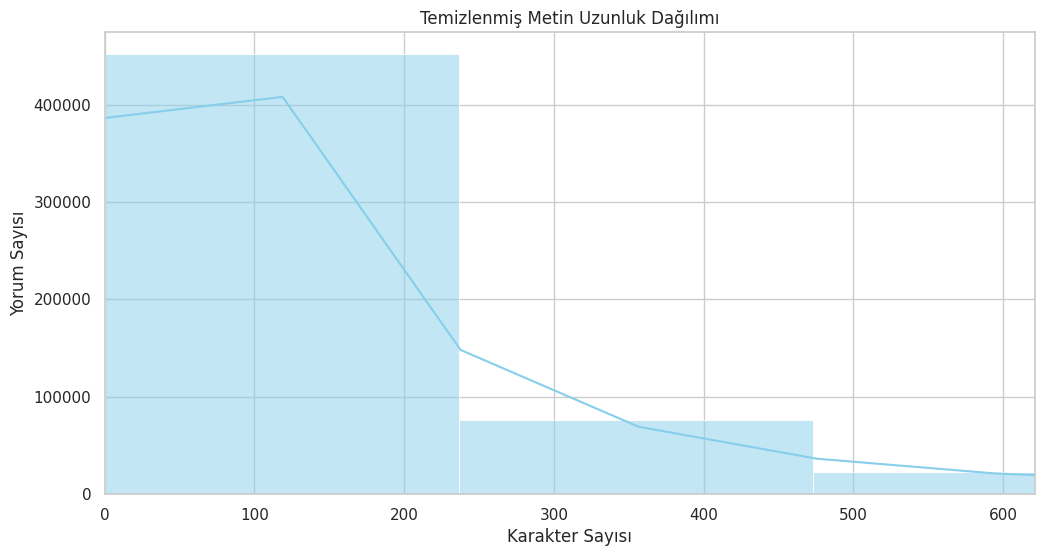

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def uzunluk_dagilimi_ciz(df):
    plt.figure(figsize=(12, 6))
    sns.histplot(df['final_text_len'], bins=100, color='skyblue', kde=True)
    plt.title('Temizlenmiş Metin Uzunluk Dağılımı')
    plt.xlabel('Karakter Sayısı')
    plt.ylabel('Yorum Sayısı')

    # Çok uzun değerler grafiği bozmasın diye x eksenini sınırlandırıp bakalım
    plt.xlim(0, df['final_text_len'].quantile(0.95))
    plt.show()

uzunluk_dagilimi_ciz(df)

In [ ]:
def aykiri_deger_temizle(df):
    baslangic_satir = len(df)

    # Alt ve üst sınırları uyguluyoruz
    # 10 karakterden büyük ve 1000 karakterden küçük yorumları filtrele
    df_filtered = df[(df['final_text_len'] >= 10) & (df['final_text_len'] <= 1000)].copy()

    bitis_satir = len(df_filtered)
    silinen = baslangic_satir - bitis_satir

    print(f"*** AYKIRI DEĞER TEMİZLİĞİ TAMAMLANDI ***")
    print(f"Başlangıç Satır Sayısı: {baslangic_satir}")
    print(f"Silinen Satır Sayısı  : {silinen}")
    print(f"Kalan Satır Sayısı     : {bitis_satir}")

    return df_filtered

# ÇALIŞTIRALIM
df = aykiri_deger_temizle(df)

*** AYKIRI DEĞER TEMİZLİĞİ TAMAMLANDI ***
Başlangıç Satır Sayısı: 573334
Silinen Satır Sayısı  : 33832
Kalan Satır Sayısı     : 539502


In [ ]:
# VERİ TEMİZLİK KONTROLÜ (DEDEKTİF HÜCRE)
import pandas as pd

# Mevcut df'deki sınırları kontrol edelim
max_deger = df['final_text_len'].max()
min_deger = df['final_text_len'].min()
toplam_satir = len(df)

print("---  MEVCUT VERİ DURUMU ---")
print(f"Toplam Satır Sayısı  : {toplam_satir}")
print(f"En Uzun Yorum        : {max_deger} karakter")
print(f"En Kısa Yorum        : {min_deger} karakter")

# Mantıksal doğrulama
if max_deger <= 1000 and min_deger >= 10:
    print("\n DURUM: Verilerin zaten 10-1000 karakter arasına çekilmiş.")

else:
    print("\n DURUM: Veri setinde hala 10-1000 aralığı dışında satırlar var!")
    print("Temizleme fonksiyonunu (df = aykiri_deger_temizle(df)) tekrar çalıştırmalısın.")

---  MEVCUT VERİ DURUMU ---
Toplam Satır Sayısı  : 539502
En Uzun Yorum        : 1000 karakter
En Kısa Yorum        : 10 karakter

 DURUM: Verilerin zaten 10-1000 karakter arasına çekilmiş.


*** TEMİZLİK SONRASI ANALİZ RAPORU ***
Kalan Toplam Satır Sayısı: 539502
Kaybedilen Veri Oranı: %0.00

Yeni Metin Uzunluğu Özet Bilgileri:
count    539502.000000
mean        158.125937
std         168.673708
min          10.000000
25%          47.000000
50%          99.000000
75%         202.000000
max        1000.000000
Name: final_text_len, dtype: float64


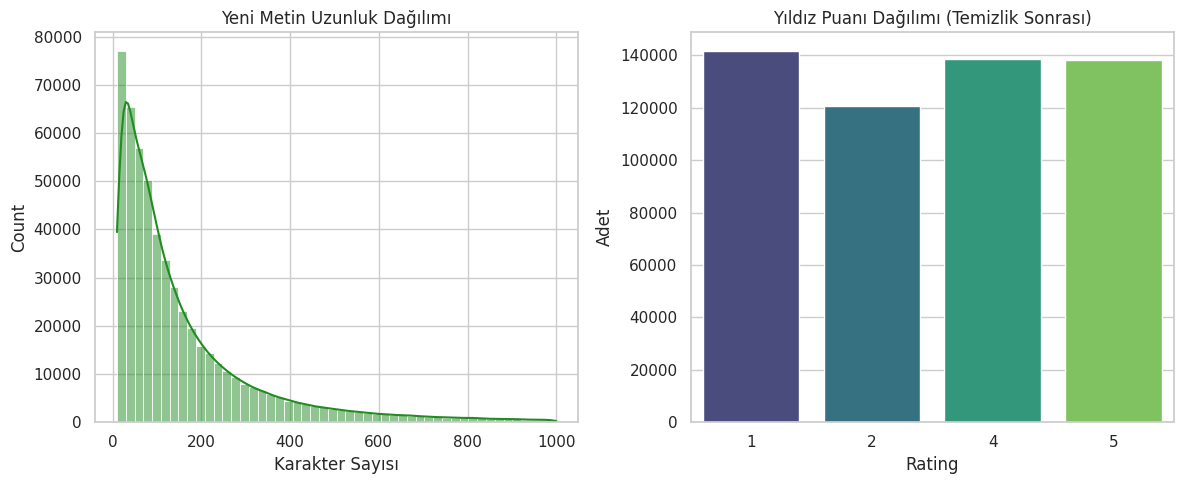


--- ÖRNEK İNCELEME ---
En Kısa Yorum (10 Karakter): fit stated
Ortalama Bir Yorum (~180 Karakter): underpart band begun tarnish leather band part faded discoloring also received promptly shipping was...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def temizlik_sonrasi_analiz(df):
    # 1. Filtreleme İşlemi (10 - 1000 karakter arası)
    df_clean = df[(df['final_text_len'] >= 10) & (df['final_text_len'] <= 1000)].copy()

    print(f"*** TEMİZLİK SONRASI ANALİZ RAPORU ***")
    print(f"Kalan Toplam Satır Sayısı: {len(df_clean)}")
    print(f"Kaybedilen Veri Oranı: %{((len(df) - len(df_clean)) / len(df) * 100):.2f}")

    # 2. Yeni Uzunluk İstatistikleri
    print("\nYeni Metin Uzunluğu Özet Bilgileri:")
    print(df_clean['final_text_len'].describe())

    # 3. Görselleştirme: Yeni Dağılım
    plt.figure(figsize=(12, 5))

    # Sol Grafik: Yeni Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_clean['final_text_len'], bins=50, color='forestgreen', kde=True)
    plt.title('Yeni Metin Uzunluk Dağılımı')
    plt.xlabel('Karakter Sayısı')

    # Sağ Grafik: Rating Dağılımı (Veri dengesini kontrol etmek için)
    plt.subplot(1, 2, 2)
    sns.countplot(x='rating', data=df_clean, palette='viridis')
    plt.title('Yıldız Puanı Dağılımı (Temizlik Sonrası)')
    plt.xlabel('Rating')
    plt.ylabel('Adet')

    plt.tight_layout()
    plt.show()

    # 4. En Uzun ve En Kısa Birer Örnek Görelim
    print("\n--- ÖRNEK İNCELEME ---")
    print(f"En Kısa Yorum (10 Karakter): {df_clean[df_clean['final_text_len'] == 10]['clean_text'].iloc[0]}")
    print(f"Ortalama Bir Yorum (~180 Karakter): {df_clean[df_clean['final_text_len'].between(175,185)]['clean_text'].iloc[0][:100]}...")

    return df_clean

# ÇALIŞTIRALIM
df = temizlik_sonrasi_analiz(df)

In [ ]:
# 1. ADIM: Label Encoding (1-2 -> 0, 4-5 -> 1)
# 3 yıldız zaten olmadığı için doğrudan haritalama yapıyoruz
df['label'] = df['rating'].map({1: 0, 2: 0, 4: 1, 5: 1})

# 2. ADIM: Kontrol ve Doğrulama
print("*** LABEL ENCODING TAMAMLANDI ***")
print(f"Toplam Satır Sayısı: {len(df)}")

print("\nEtiket Dağılımı (Sayısal):")
print(df['label'].value_counts())

print("\nEtiket Dağılımı (Yüzdesel):")
print(df['label'].value_counts(normalize=True))

# Tablonun ilk 5 satırını ve yeni etiketi görelim
display(df[['rating', 'label', 'clean_text']].head())

*** LABEL ENCODING TAMAMLANDI ***
Toplam Satır Sayısı: 539502

Etiket Dağılımı (Sayısal):
label
1    276974
0    262528
Name: count, dtype: int64

Etiket Dağılımı (Yüzdesel):
label
1    0.513388
0    0.486612
Name: proportion, dtype: float64


,rating,label,clean_text
0,1,0,previously purchased band wire 6 months straig...
1,1,0,slim nine year old small way small large way l...
2,1,0,band recieved pictured got band narrow end ins...
3,1,0,didnt come color shown
4,1,0,work get one side band strap holders buckle wa...


In [ ]:
print(df.columns)

Index(['main_category', 'parent_asin', 'user_id', 'rating', 'title', 'text',
       'timestamp', 'helpful_vote', 'verified_purchase', 'char_count',
       'word_count', 'exclamation_count', 'question_count', 'uppercase_count',
       'clean_title', 'clean_text', 'final_text_len', 'label'],
      dtype='object')


In [ ]:
# Ortalama kelime uzunluğunu hesaplayalım
# (Karakter sayısını kelime sayısına bölüyoruz)
df['avg_word_len'] = df['char_count'] / df['word_count']

# Sonsuz değer veya hata oluşursa (0'a bölünme gibi) onları temizleyelim
df['avg_word_len'] = df['avg_word_len'].fillna(0)

print(" 'avg_word_len' sütunu başarıyla oluşturuldu.")
display(df[['clean_text', 'avg_word_len']].head())

✅ 'avg_word_len' sütunu başarıyla oluşturuldu.


,clean_text,avg_word_len
0,previously purchased band wire 6 months straig...,5.604651
1,slim nine year old small way small large way l...,4.913043
2,band recieved pictured got band narrow end ins...,4.666667
3,didnt come color shown,5.000000
4,work get one side band strap holders buckle wa...,4.625000


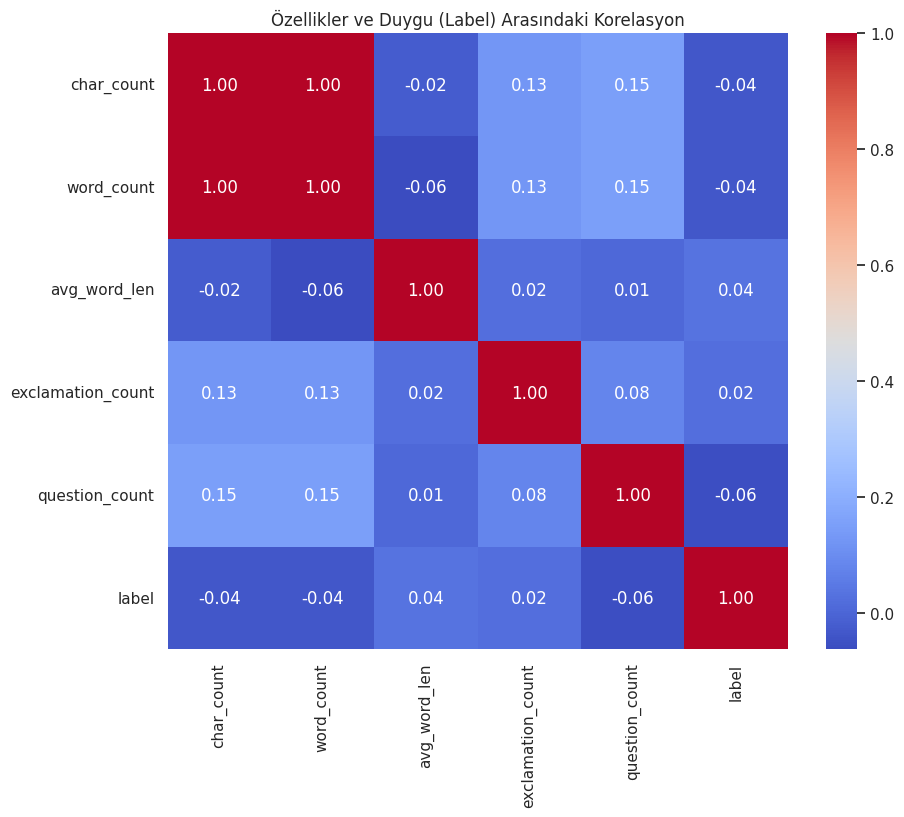


*** ÖZELLİK SEÇİMİ ANALİZİ ***
label                1.000000
avg_word_len         0.037373
exclamation_count    0.022247
word_count          -0.036404
char_count          -0.037180
question_count      -0.055935
Name: label, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Analiz edilecek tam liste
analiz_listesi = ['char_count', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'label']

# Korelasyon Matrisi
korelasyon_df = df[analiz_listesi].corr()

# Isı Haritası Görselleştirme
plt.figure(figsize=(10, 8))
sns.heatmap(korelasyon_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Özellikler ve Duygu (Label) Arasındaki Korelasyon')
plt.show()

# Label ile en çok ilişkili olanları sıralayalım
print("\n*** ÖZELLİK SEÇİMİ ANALİZİ ***")
print(korelasyon_df['label'].sort_values(ascending=False))

In [ ]:
# Özellik seçimi kararımıza göre gereksiz sütunları uçuralım
df_final = df.drop(columns=['word_count', 'rating'])

print(" ÖZELLİK SEÇİMİ TAMAMLANDI ")
print(f"Kalan Sütunlar: {df_final.columns.tolist()}")

# Tablonun son halini kontrol et
display(df_final.head())

 ÖZELLİK SEÇİMİ TAMAMLANDI 
Kalan Sütunlar: ['main_category', 'parent_asin', 'user_id', 'title', 'text', 'timestamp', 'helpful_vote', 'verified_purchase', 'char_count', 'exclamation_count', 'question_count', 'uppercase_count', 'clean_title', 'clean_text', 'final_text_len', 'label', 'avg_word_len']


,main_category,parent_asin,user_id,title,text,timestamp,helpful_vote,verified_purchase,char_count,exclamation_count,question_count,uppercase_count,clean_title,clean_text,final_text_len,label,avg_word_len
0,AMAZON FASHION,B07C1JV4D6,AHFNZX5F56JGJB3YNWA57ZN4APXA,Decrease in quality,I previously purchased this band and wire it f...,1580012908597,0,True,241,0,0,5,decrease quality,previously purchased band wire 6 months straig...,146,0,5.604651
1,AMAZON FASHION,B07Y1WXKK7,AGKJS7CWFAIMUF3XSZBD2PLYWPJA,Sizing is poor,For slim nine year old the small was way too s...,1628407422155,0,True,113,0,0,3,sizing poor,slim nine year old small way small large way l...,75,0,4.913043
2,AMAZON FASHION,B0B5LM3BM4,AHPWHEPY6LTUH3GAB6B2CXAEJ5GQ,Band not as pictured,The band I recieved is NOT what was pictured. ...,1607109744225,0,True,112,0,0,6,band pictured,band recieved pictured got band narrow end ins...,57,0,4.666667
3,AMAZON FASHION,B07RM3SH7T,AGCXKLCXMUBUGFDY4EIE6FISFLWQ,Didn't come in color that was shown,Didn't come in color that was shown,1646075961857,0,True,35,0,0,1,didnt come color shown,didnt come color shown,22,0,5.000000
4,AMAZON FASHION,B093RXLDX3,AEMPA7MRAT4S6MZHV4W3GTBZVKRQ,Don’t buy,They do not work! You can not get the one side...,1675717611577,0,True,185,3,0,5,dont buy,work get one side band strap holders buckle wa...,91,0,4.625000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Ölçeklenecek sayısal sütunlar (Sadece gerçekten sayı olanlar)
sayisal_sutunlar = ['char_count', 'avg_word_len', 'exclamation_count', 'question_count']

# 2. Scaler (Ölçekleyici) hazırlığı
scaler = MinMaxScaler()

# 3. Dönüştürme işlemi
df_final[sayisal_sutunlar] = scaler.fit_transform(df_final[sayisal_sutunlar])

print("*** ÖLÇEKLEME (NORMALİZASYON) TAMAMLANDI ***")
print("Tüm sayısal değerler artık 0 ile 1 arasında.")

# Kontrol edelim
display(df_final[sayisal_sutunlar].describe())

*** ÖLÇEKLEME (NORMALİZASYON) TAMAMLANDI ***
Tüm sayısal değerler artık 0 ile 1 arasında.


,char_count,avg_word_len,exclamation_count,question_count
count,539502.000000,539502.000000,539502.000000,539502.000000
mean,0.096011,0.069958,0.003712,0.000656
std,0.107964,0.018013,0.012586,0.005103
min,0.000000,0.000000,0.000000,0.000000
25%,0.024706,0.061433,0.000000,0.000000
50%,0.058039,0.068123,0.000000,0.000000
75%,0.124314,0.075403,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Son halini Drive'a kaydedelim
# Bu dosya tüm ön işleme adımlarından geçmiş (Scaling, Encoding, Selection yapılmış) halidir.
output_file_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/amazon_reviews_preprocessed_FINAL.csv'

df_final.to_csv(output_file_path, index=False)

print(f" İŞLEM TAMAMLANDI!")
print(f"Final Veri Seti Şuraya Kaydedildi: {output_file_path}")
print(f"Toplam Satır Sayısı: {len(df_final)}")
print(f"Kalan Sütunlar: {df_final.columns.tolist()}")

 İŞLEM TAMAMLANDI!
Final Veri Seti Şuraya Kaydedildi: /content/drive/MyDrive/Veri_madenciliği/Dataset/amazon_reviews_preprocessed_FINAL.csv
Toplam Satır Sayısı: 539502
Kalan Sütunlar: ['main_category', 'parent_asin', 'user_id', 'title', 'text', 'timestamp', 'helpful_vote', 'verified_purchase', 'char_count', 'exclamation_count', 'question_count', 'uppercase_count', 'clean_title', 'clean_text', 'final_text_len', 'label', 'avg_word_len']
